In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"

In [3]:
# Fetch the dataset from the original URL
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

# Format the data to match the old 'load_boston' structure
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

print("Data loaded successfully!")

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\joshu\AppData\Local\Temp\ipykernel_9200\1973930865.py:3: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


Data loaded successfully!


In [4]:
df=pd.DataFrame(data)

df

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48


In [7]:
df.columns = feature_names
print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  
0     15.3  396.90   4.98  
1     17.8  396.90   9.14  
2     17.8  392.83   4.03  
3     18.7  394.63   2.94  
4     18.7  396.90   5.33  


In [6]:
# 1. Define the names
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']





In [8]:
# 3. Add the price column (target) so you have the full dataset
df['PRICE'] = target

# 4. View it
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  PRICE    506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


In [10]:
##Summarizing the stats of the data
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [11]:
##Checking Missing values


df.isna().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64

In [12]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'PRICE'],
      dtype='object')

In [13]:
##EDA
##Coorelation

df.corr()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


Text(0, 0.5, 'PRICE')

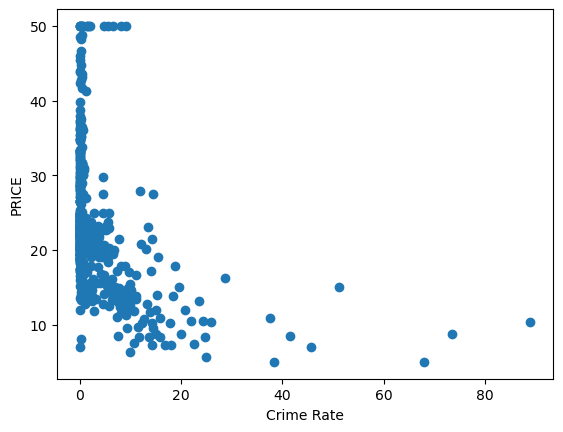

In [14]:
import matplotlib.pyplot as plt
plt.scatter(df['CRIM'],df['PRICE'])
plt.xlabel("Crime Rate")
plt.ylabel("PRICE")

Text(0, 0.5, 'PRICE')

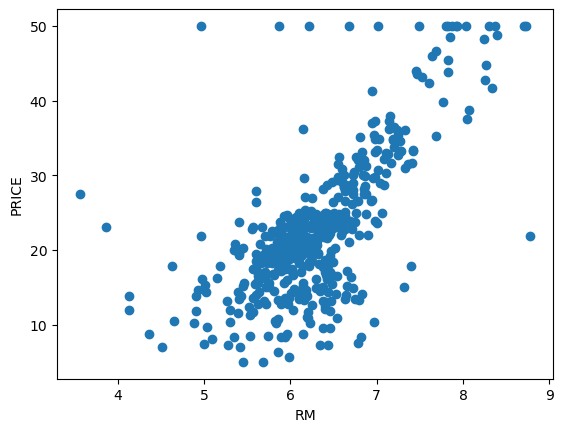

In [15]:
plt.scatter(df['RM'],df['PRICE'])
plt.xlabel("RM")
plt.ylabel("PRICE")

<Axes: xlabel='RM', ylabel='PRICE'>

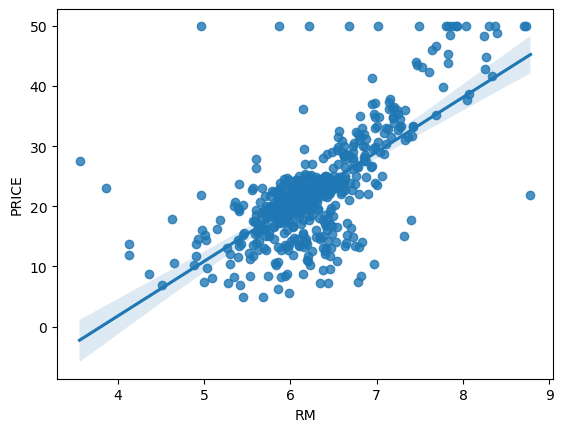

In [16]:
sns.regplot(x="RM",y="PRICE", data=df)

<Axes: xlabel='LSTAT', ylabel='PRICE'>

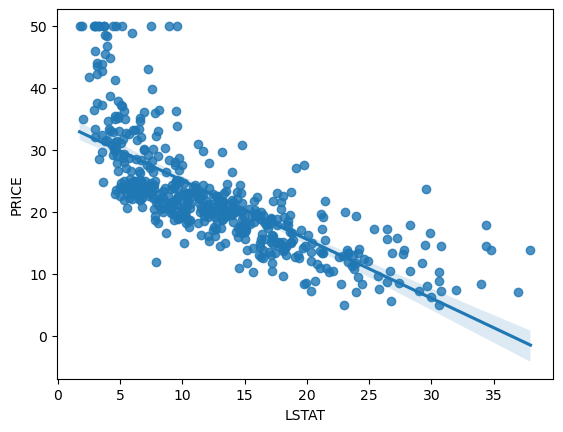

In [17]:
sns.regplot(x="LSTAT",y="PRICE", data=df)

In [18]:
##INdependent and dependent features



X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [19]:
X

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48


In [20]:
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: PRICE, Length: 506, dtype: float64

In [21]:
##Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.3,random_state=4) 


In [22]:
X_train

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
84,0.05059,0.0,4.49,0.0,0.449,6.389,48.0,4.7794,3.0,247.0,18.5,396.90,9.62
354,0.04301,80.0,1.91,0.0,0.413,5.663,21.9,10.5857,4.0,334.0,22.0,382.80,8.05
221,0.40771,0.0,6.20,1.0,0.507,6.164,91.3,3.0480,8.0,307.0,17.4,395.24,21.46
34,1.61282,0.0,8.14,0.0,0.538,6.096,96.9,3.7598,4.0,307.0,21.0,248.31,20.34
267,0.57834,20.0,3.97,0.0,0.575,8.297,67.0,2.4216,5.0,264.0,13.0,384.54,7.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...
385,16.81180,0.0,18.10,0.0,0.700,5.277,98.1,1.4261,24.0,666.0,20.2,396.90,30.81
197,0.04666,80.0,1.52,0.0,0.404,7.107,36.6,7.3090,2.0,329.0,12.6,354.31,8.61
439,9.39063,0.0,18.10,0.0,0.740,5.627,93.9,1.8172,24.0,666.0,20.2,396.90,22.88
174,0.08447,0.0,4.05,0.0,0.510,5.859,68.7,2.7019,5.0,296.0,16.6,393.23,9.64


In [23]:
X_test

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
8,0.21124,12.5,7.87,0.0,0.524,5.631,100.0,6.0821,5.0,311.0,15.2,386.63,29.93
289,0.04297,52.5,5.32,0.0,0.405,6.565,22.9,7.3172,6.0,293.0,16.6,371.72,9.51
68,0.13554,12.5,6.07,0.0,0.409,5.594,36.8,6.4980,4.0,345.0,18.9,396.90,13.09
211,0.37578,0.0,10.59,1.0,0.489,5.404,88.6,3.6650,4.0,277.0,18.6,395.24,23.98
226,0.38214,0.0,6.20,0.0,0.504,8.040,86.5,3.2157,8.0,307.0,17.4,387.38,3.13
...,...,...,...,...,...,...,...,...,...,...,...,...,...
446,6.28807,0.0,18.10,0.0,0.740,6.341,96.4,2.0720,24.0,666.0,20.2,318.01,17.79
364,3.47428,0.0,18.10,1.0,0.718,8.780,82.9,1.9047,24.0,666.0,20.2,354.55,5.29
337,0.03041,0.0,5.19,0.0,0.515,5.895,59.6,5.6150,5.0,224.0,20.2,394.81,10.56
39,0.02763,75.0,2.95,0.0,0.428,6.595,21.8,5.4011,3.0,252.0,18.3,395.63,4.32


In [24]:
## Stanndardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [25]:
X_train=scaler.fit_transform(X_train)

In [26]:
X_test=scaler.transform(X_test)

In [27]:
import pickle
pickle.dump(scaler,open('scaling.pkl','wb'))

In [28]:
X_train

array([[-0.42546852, -0.47076769, -0.95468627, ...,  0.00545961,
         0.44188904, -0.44481854],
       [-0.42632345,  2.99257588, -1.3301574 , ...,  1.61604587,
         0.28749838, -0.66643827],
       [-0.3851898 , -0.47076769, -0.7058275 , ..., -0.50072464,
         0.42371255,  1.22650481],
       ...,
       [ 0.62797244, -0.47076769,  1.02599668, ...,  0.78774436,
         0.44188904,  1.42695069],
       [-0.42164728, -0.47076769, -1.01872011, ..., -0.86885864,
         0.40170367, -0.44199536],
       [-0.42068632, -0.47076769,  2.12475908, ...,  0.28156011,
         0.23592534,  0.72821331]])

#### Model Training

In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
lin_reg= LinearRegression()

In [30]:
lin_reg.fit(X_train,y_train) ##Training the model

LinearRegression()

In [31]:
## print the cooefficients and Intercept
print(lin_reg.coef_)  ##Cooefficients of each features

[-1.08673085  1.28610283 -0.0607036   1.03108551 -1.6887816   2.16731202
 -0.09530735 -3.32627056  2.88971894 -2.39272265 -1.74561418  0.85424206
 -3.70842299]


In [32]:
print(lin_reg.intercept_)

22.122316384180788


In [33]:
##on which parameters the model has been 
lin_reg.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

In [34]:
### Prediction with Test data
y_pred=lin_reg.predict(X_test)

In [35]:
y_pred

array([11.07380893, 26.47910329, 17.34489869, 19.1948608 , 36.36170735,
       24.77095832, 31.00051311, 19.94226881, 19.22375105, 24.42998435,
       28.31512637, 28.40796034, 19.27427968, 33.82295207, 21.28596487,
       15.11171444, 20.97688767, 11.28556596, 11.8611348 , 13.88444387,
        5.37422679, 17.55278177, 20.58171204, 22.59849951, 16.07544265,
       20.45924503, 19.1068775 , 14.37832191, 21.23235601, 17.52186564,
       14.40725559, 23.68483414, 33.7410661 , 22.02733357, 17.62139147,
       19.97241153, 30.24069397, 34.69718954, 23.85821534, 24.30715093,
       36.13378112, 31.97532293, 19.626175  , 31.61097971, 34.58127809,
       25.62718797, 39.95041812, 17.60880538, 19.90319708, 23.40417501,
       33.70182396, 25.62491083, 18.25559302, 27.27317174, 13.46377871,
       23.43470656, 24.43721849, 33.52056736, 16.99896935, 37.94464404,
       15.94567818, 19.32528916, 31.84088262, 15.25081303, 38.40344789,
       27.45372884, 34.36154312,  9.37353936, 19.42580066, 21.99

## Assumptions

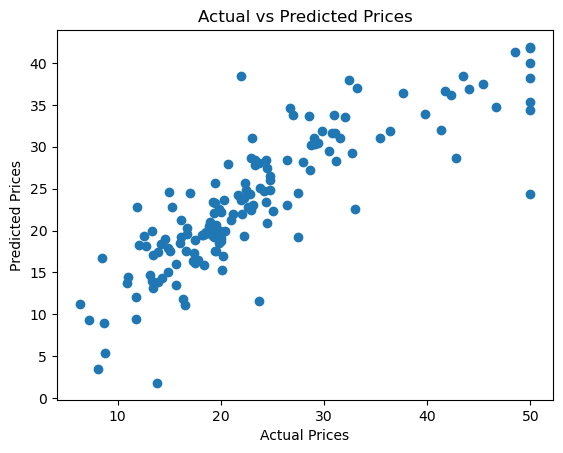

In [36]:
### Plot a scatter for prediction
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()


In [37]:
##  Rediduals is error between actual and predicted values
residuals=y_test-y_pred
residuals

8       5.426191
289    -1.679103
68      0.055101
211     0.105139
226     1.238293
         ...    
446    -2.991931
364   -16.539440
337    -1.207526
39     -0.871812
478    -4.413091
Name: PRICE, Length: 152, dtype: float64

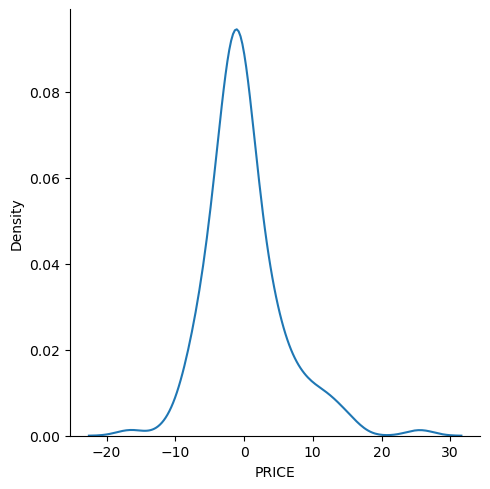

In [38]:
##Plotting the residuals
sns.displot(residuals, kind="kde")


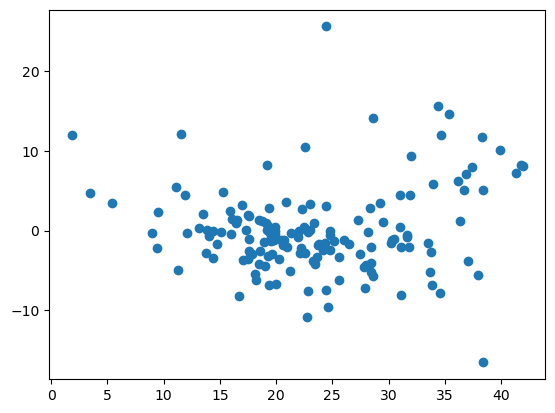

In [39]:
## Scatter plot with respect to prediction and residuals
##Uniform distribution of residuals around zero is a good sign for linear regression model
plt.scatter(y_pred,residuals)

In [40]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [41]:
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test, y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

3.8590055923707465
30.05399330712423
5.482152251362984


### R square and adjusted R square
######   Formula
###### R^2 = SSR/SST
###### coefficient of determination SSR= sum of squares of residuals , SST= total sum of squares

In [42]:
from sklearn.metrics import r2_score
score= r2_score(y_test, y_pred)
print(score) ##Better model has score closer to 1

0.7121818377409186


## New data prediction

In [43]:
data[0].reshape(1,-1).shape

(1, 13)

In [44]:
lin_reg.predict(data[0].reshape(1,-1)) ##Before standardization of new data

array([-372.83525603])

In [45]:
scaler.transform(data[0].reshape(1,-1)) ##Standardization of new data

c:\Users\joshu\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[-0.43046163,  0.30848461, -1.27194482, -0.23145502, -0.15880531,
         0.49659823, -0.12519346,  0.13232641, -0.99026801, -0.68794622,
        -1.46707639,  0.44188904, -1.09979661]])

In [46]:
lin_reg.predict(scaler.transform(data[0].reshape(1,-1))) ##Prediction with new data after standardization

c:\Users\joshu\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([29.54307499])

## Pickling the model file for Deployment

In [47]:
import pickle

In [48]:
pickle.dump(lin_reg, open("reg_model.pkl", 'wb'))##right byte mode

In [49]:
pickle_model=pickle.load(open("reg_model.pkl", 'rb'))  ##Read byte mode

In [50]:
## prediction with new data after standardization using loaded model
pickle_model.predict(scaler.transform(data[0].reshape(1,-1))) ##Prediction with new data after standardization using loaded model

c:\Users\joshu\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([29.54307499])